# Before Running the Notebook:
This Notebook is designed to run in *Google Colab* on a GPU using cuda. Upload the `data_bert_sample.parquet` file to the colab environment and follow the instructions below to execute it.

The Colab environment has torchvision installed by default, which leads to an error due to version conflicts in the `run_bert_classifier()` function. Before you execute all chunks in this notebook:
- run the first chunk with `!pip uninstall -y torchvision`
- restart the session (Runtime → Restart Session)

Afterwards, you can run all chunks.

In [ ]:
!pip uninstall -y torchvision

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, precision_score, recall_score, confusion_matrix
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

import json

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [ ]:
df = pd.read_parquet("data_bert_sample.parquet")
df["is_science"] = df["is_science"].astype(int)
display(df.head())
print(df["is_science"].value_counts())

,content,summary,is_science
0,I dropped a 120ug LSD tab a week ago for the f...,of this would be…\nDid LSD for first time last...,0
1,I've only seen a few clips of Lucha Undergroun...,you don't have to understand the commentary fo...,0
2,I find myself doing this from time to time and...,thank you /r/microgrowery for helping me into ...,0
3,"okay, I am going to start a lets play and I am...",you choose pretty much everything for lets pla...,0
4,Nothing much today I'm going to keep it simple...,"Normal day, didn't exercise, played battlefiel...",0


is_science
0    3000
1    3000
Name: count, dtype: int64


In [ ]:
tokenizer_check = AutoTokenizer.from_pretrained("bert-base-uncased")

content_lengths = [len(tokenizer_check.encode(t)) for t in pd.Series(df["content"])]
summary_lengths = [len(tokenizer_check.encode(t)) for t in pd.Series(df["summary"])]


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1289 > 512). Running this sequence through the model will result in indexing errors


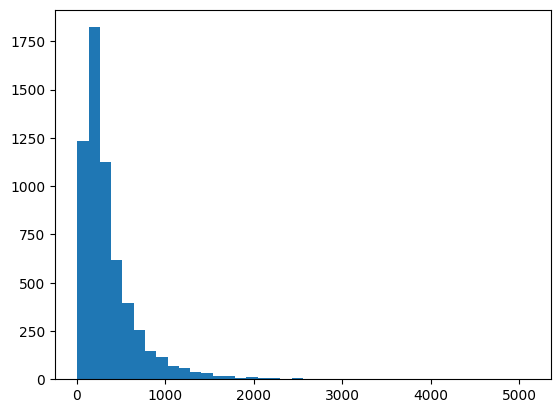

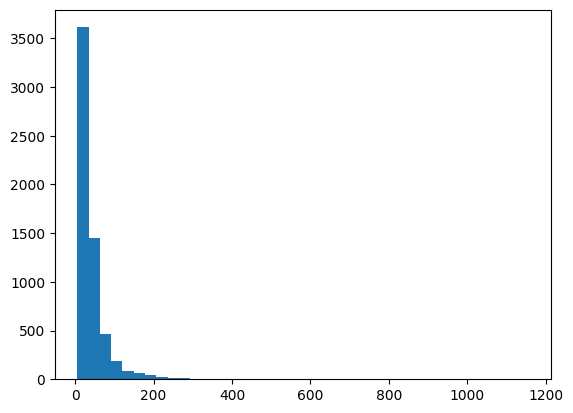

Fraction of content inputs which were truncated: 0.20433333333333334
Fraction of summary inputs which were truncated: 0.011333333333333334


In [ ]:
import matplotlib.pyplot as plt
plt.hist(content_lengths, bins=40)
plt.show()
plt.hist(summary_lengths, bins=40)
plt.show()

frac_truncated_content = len([l for l in content_lengths if l > 512])/len(content_lengths)
frac_truncated_summary = len([l for l in summary_lengths if l > 256])/len(summary_lengths)

print(f"Fraction of content inputs which were truncated: {frac_truncated_content}")
print(f"Fraction of summary inputs which were truncated: {frac_truncated_summary}")

In [ ]:
CONTENT_MAX_LEN = 512
SUMMARY_MAX_LEN = 256

In [ ]:
#splitting into train, eval and test dataframes

train_df, holdout_df = train_test_split(
    df, test_size=2000, stratify=df["is_science"], random_state=42
)
eval_df, test_df = train_test_split(
    holdout_df, test_size=1000, stratify=holdout_df["is_science"], random_state=42
)
print(f"Train: {len(train_df)}  Eval: {len(eval_df)}  Test: {len(test_df)}")
print(train_df["is_science"].value_counts())
print(eval_df["is_science"].value_counts())
print(test_df["is_science"].value_counts())

Train: 4000  Eval: 1000  Test: 1000
is_science
1    2000
0    2000
Name: count, dtype: int64
is_science
1    500
0    500
Name: count, dtype: int64
is_science
1    500
0    500
Name: count, dtype: int64


In [ ]:
MODEL_NAME = "bert-base-uncased"

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = np.argmax(logits, axis=1)
    return {
    "accuracy": float(accuracy_score(labels, preds)),
    "precision": float(precision_score(labels, preds)),
    "recall": float(recall_score(labels, preds)),
    "f1": float(f1_score(labels, preds)),
    "roc_auc": float(roc_auc_score(labels, probs)),
}


In [ ]:
def run_bert_classifier(train_df, eval_df, test_df, text_col, max_len, output_dir, epochs=5, batch_size=16):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    train_ds = Dataset.from_pandas(train_df[[text_col, "is_science"]].rename(columns={text_col: "text", "is_science": "labels"}))
    eval_ds = Dataset.from_pandas(eval_df[[text_col, "is_science"]].rename(columns={text_col: "text", "is_science": "labels"}))
    test_ds = Dataset.from_pandas(test_df[[text_col, "is_science"]].rename(columns={text_col: "text", "is_science": "labels"}))

    train_ds = train_ds.map(lambda b: tokenizer(b["text"], truncation=True, padding="max_length", max_length=max_len), batched=True)
    eval_ds = eval_ds.map(lambda b: tokenizer(b["text"], truncation=True, padding="max_length", max_length=max_len), batched=True)
    test_ds = test_ds.map(lambda b: tokenizer(b["text"], truncation=True, padding="max_length", max_length=max_len), batched=True)

    train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    eval_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

    args = TrainingArguments(
        learning_rate = 5e-5,
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="roc_auc",
        logging_steps=50,
        seed=SEED,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()

    # Final metrics are computed on the held-out test set (never seen during training or model selection)
    test_output = trainer.predict(test_ds)
    metrics = compute_metrics((test_output.predictions, test_output.label_ids))
    preds = np.argmax(test_output.predictions, axis=1)

    #confusion matrices:
    cm = confusion_matrix(test_df["is_science"], preds)

    print(f"\n=== {text_col.upper()} classification report (test set) ===")
    print(classification_report(test_df["is_science"], preds))

    return trainer, metrics, cm

In [ ]:
content_trainer, content_metrics, content_cm = run_bert_classifier(
    train_df, eval_df, test_df, text_col="content", max_len=CONTENT_MAX_LEN, output_dir="./bert_content"
)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


=== CONTENT classification report (test set) ===
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       500
           1       0.95      0.96      0.96       500

    accuracy                           0.95      1000
   macro avg       0.96      0.95      0.95      1000
weighted avg       0.96      0.95      0.95      1000



In [ ]:
summary_trainer, summary_metrics, summary_cm = run_bert_classifier(
    train_df, eval_df, test_df, text_col="summary", max_len=SUMMARY_MAX_LEN, output_dir="./bert_summary"
)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


=== SUMMARY classification report (test set) ===
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       500
           1       0.85      0.89      0.87       500

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



In [ ]:
# save classification results

def clean_metrics(metrics_dict):
  return {k: float(v) if isinstance(v, (np.floating, np.integer)) else v
          for k, v in metrics_dict.items()}

results = {
    "content": {
        "token_lengths": content_lengths,
        **clean_metrics(content_metrics),
        "confusion_matrix": content_cm.tolist()
        },
    "summary": {
        "token_lengths": summary_lengths,
        **clean_metrics(summary_metrics),
        "confusion_matrix": summary_cm.tolist()
    }
}

with open("bert_results.json", "w") as f:
  json.dump(results, f)